### Importando as bibliotecas

In [234]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

### Fazendo a leitura dos dados e tirando as colunas que não serão utilizadas

In [235]:
standard_df = pd.read_csv('..\\data\\player-standard-stats.csv', index_col=0)
miscellaneous_df = pd.read_csv('..\\data\\player-miscellaneous-stats.csv', index_col=0)

In [236]:
standard_df.head()

,Player,Nation,Pos,Squad,Age,Born,MP,Starts,Min,90s,...,PKatt,CrdY,CrdR,Gls.1,Ast.1,G+A.1,G-PK.1,G+A-PK,Matches,-9999
Rk,,,,,,,,,,,,,,,,,,,,,
1,Abner,br BRA,DF,Juventude,20,2004,19,13,1318,14.6,...,0,3,0,0.00,0.07,0.07,0.00,0.07,Matches,6c0ef11c
2,Nicolás Acevedo,uy URU,MF,Bahia,25,1999,32,18,1690,18.8,...,0,6,0,0.00,0.05,0.05,0.00,0.05,Matches,6140be7b
3,Luciano Acosta,ar ARG,MF,Fluminense,30,1994,16,15,1199,13.3,...,0,5,0,0.23,0.15,0.38,0.23,0.38,Matches,363ba6d7
4,Adriel,br BRA,MF,Sport Recife,18,2006,5,1,148,1.6,...,0,1,0,0.00,0.00,0.00,0.00,0.00,Matches,959e965c
5,Adson,br BRA,MF,Vasco da Gama,24,2000,10,0,210,2.3,...,0,0,0,0.00,0.00,0.00,0.00,0.00,Matches,eda38706


In [237]:
miscellaneous_df.head()

,Player,Nation,Pos,Squad,Age,Born,90s,CrdY,CrdR,2CrdY,...,Fld,Off,Crs,Int,TklW,PKwon,PKcon,OG,Matches,-9999
Rk,,,,,,,,,,,,,,,,,,,,,
1,Abner,br BRA,DF,Juventude,20,2004,14.6,3,0,0,...,5,1,0,18,11,NaN,NaN,0,Matches,6c0ef11c
2,Nicolás Acevedo,uy URU,MF,Bahia,25,1999,18.8,6,0,0,...,28,0,10,30,42,NaN,NaN,0,Matches,6140be7b
3,Luciano Acosta,ar ARG,MF,Fluminense,30,1994,13.3,5,0,0,...,25,2,37,0,15,NaN,NaN,0,Matches,363ba6d7
4,Adriel,br BRA,MF,Sport Recife,18,2006,1.6,1,0,0,...,0,0,0,2,3,NaN,NaN,0,Matches,959e965c
5,Adson,br BRA,MF,Vasco da Gama,24,2000,2.3,0,0,0,...,3,0,7,0,3,NaN,NaN,0,Matches,eda38706


##### Dropando as colunas que já receberam a padronização de estatísticas por 90 minutos e que não vão ser usadas no JOIN

In [238]:
standard_df = standard_df.drop(columns=['Gls.1', 'Ast.1', 'G+A.1', 'G-PK.1', 'G+A-PK','Matches', '-9999'])
miscellaneous_df = miscellaneous_df.drop(columns=['Player', 'Nation', 'Pos', 'Squad', 'Age', 'Born', '90s', 'CrdY', 'CrdR', 'Matches', '-9999'])

### Fazendo o JOIN entre os dois csv's

In [239]:
stats_df = pd.merge(standard_df, miscellaneous_df, on='Rk', how='inner')

In [240]:
stats_df.head()

,Player,Nation,Pos,Squad,Age,Born,MP,Starts,Min,90s,...,2CrdY,Fls,Fld,Off,Crs,Int,TklW,PKwon,PKcon,OG
Rk,,,,,,,,,,,,,,,,,,,,,
1,Abner,br BRA,DF,Juventude,20,2004,19,13,1318,14.6,...,0,16,5,1,0,18,11,NaN,NaN,0
2,Nicolás Acevedo,uy URU,MF,Bahia,25,1999,32,18,1690,18.8,...,0,44,28,0,10,30,42,NaN,NaN,0
3,Luciano Acosta,ar ARG,MF,Fluminense,30,1994,16,15,1199,13.3,...,0,27,25,2,37,0,15,NaN,NaN,0
4,Adriel,br BRA,MF,Sport Recife,18,2006,5,1,148,1.6,...,0,7,0,0,0,2,3,NaN,NaN,0
5,Adson,br BRA,MF,Vasco da Gama,24,2000,10,0,210,2.3,...,0,2,3,0,7,0,3,NaN,NaN,0


In [241]:
stats_df.to_csv('..\\data\\player-stats.csv')

In [242]:
stats_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 761 entries, 1 to 761
Data columns (total 28 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Player  761 non-null    str    
 1   Nation  761 non-null    str    
 2   Pos     761 non-null    str    
 3   Squad   761 non-null    str    
 4   Age     761 non-null    int64  
 5   Born    761 non-null    int64  
 6   MP      761 non-null    int64  
 7   Starts  761 non-null    int64  
 8   Min     761 non-null    int64  
 9   90s     761 non-null    float64
 10  Gls     761 non-null    int64  
 11  Ast     761 non-null    int64  
 12  G+A     761 non-null    int64  
 13  G-PK    761 non-null    int64  
 14  PK      761 non-null    int64  
 15  PKatt   761 non-null    int64  
 16  CrdY    761 non-null    int64  
 17  CrdR    761 non-null    int64  
 18  2CrdY   761 non-null    int64  
 19  Fls     761 non-null    int64  
 20  Fld     761 non-null    int64  
 21  Off     761 non-null    int64  
 22  Crs     761 n

In [243]:
stats_df.describe()

,Age,Born,MP,Starts,Min,90s,Gls,Ast,G+A,G-PK,...,2CrdY,Fls,Fld,Off,Crs,Int,TklW,PKwon,PKcon,OG
count,761.000000,761.000000,761.000000,761.000000,761.000000,761.000000,761.000000,761.000000,761.000000,761.000000,...,761.000000,761.000000,761.000000,761.000000,761.000000,761.000000,761.000000,0.0,0.0,761.000000
mean,25.932983,1998.160315,15.766097,10.985545,985.625493,10.951511,1.229961,0.852825,2.082786,1.111695,...,0.039422,13.814717,13.102497,1.501971,18.465177,8.162943,10.462549,NaN,NaN,0.030223
std,5.269023,5.276617,10.684369,10.165398,856.659389,9.519151,2.384367,1.533622,3.463301,2.103101,...,0.207800,13.449656,15.334430,3.017983,31.192343,9.840290,11.724535,NaN,NaN,0.171314
min,15.000000,1980.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,0.000000
25%,22.000000,1994.000000,6.000000,2.000000,249.000000,2.800000,0.000000,0.000000,0.000000,0.000000,...,0.000000,2.000000,2.000000,0.000000,0.000000,1.000000,1.000000,NaN,NaN,0.000000
50%,26.000000,1998.000000,15.000000,8.000000,791.000000,8.800000,0.000000,0.000000,1.000000,0.000000,...,0.000000,10.000000,8.000000,0.000000,5.000000,4.000000,6.000000,NaN,NaN,0.000000
75%,30.000000,2002.000000,25.000000,17.000000,1499.000000,16.700000,1.000000,1.000000,3.000000,1.000000,...,0.000000,21.000000,18.000000,2.000000,23.000000,12.000000,16.000000,NaN,NaN,0.000000
max,44.000000,2009.000000,38.000000,38.000000,3420.000000,38.000000,21.000000,14.000000,32.000000,20.000000,...,2.000000,75.000000,111.000000,33.000000,206.000000,61.000000,76.000000,NaN,NaN,1.000000


## Hipóteses orientadas a gráfico

### H1 — Existe separação visual entre posições nas taxas por-90?

**Hipótese:** olhando a distribuição de cada estatística dos jogadores (convertida para por-90 diretamente das colunas brutas) agrupada por posição primária (GK/DF/MF/FW), pelo menos algumas features mostram medianas e caixas claramente distintas entre grupos.

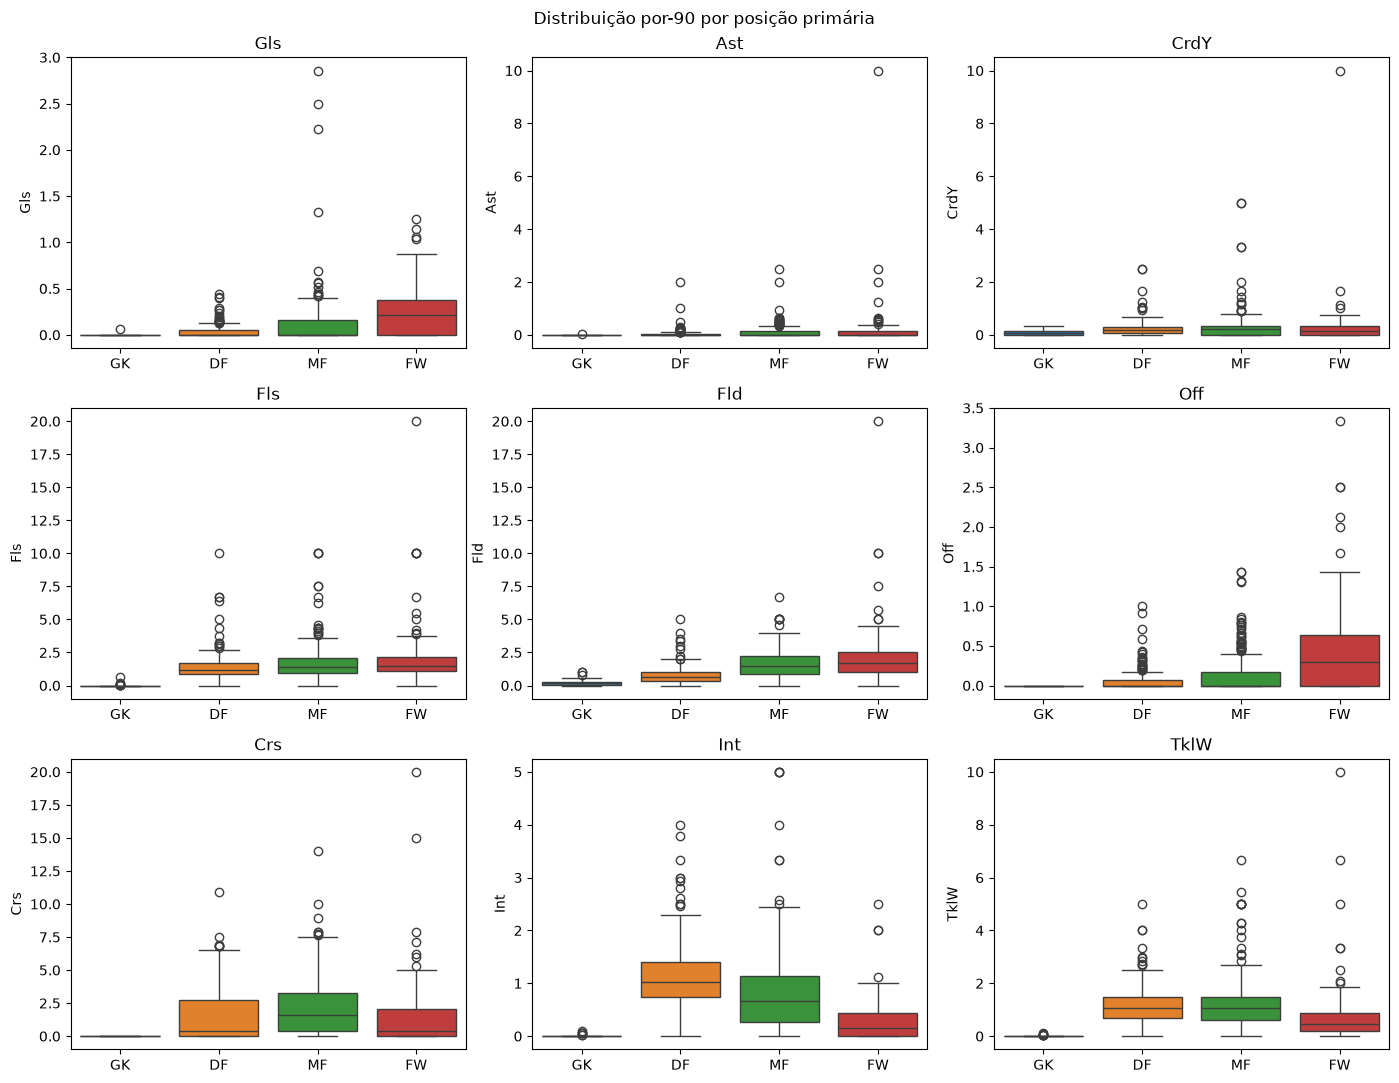

In [244]:
colunas_evento = ['Gls', 'Ast', 'CrdY', 'Fls', 'Fld', 'Off', 'Crs', 'Int', 'TklW']

por90 = stats_df[colunas_evento].div(stats_df['90s'].replace(0, np.nan), axis=0)
por90['Pos_primaria'] = stats_df['Pos'].str[:2]

fig, axes = plt.subplots(3, 3, figsize=(14, 11))
ordem_pos = ['GK', 'DF', 'MF', 'FW']

for ax, col in zip(axes.flat, colunas_evento):
    sns.boxplot(data=por90, x='Pos_primaria', y=col, order=ordem_pos, ax=ax, hue='Pos_primaria', palette={'GK': '#1f77b4', 'DF': '#ff7f0e', 'MF': '#2ca02c', 'FW': '#d62728'})
    ax.set_title(col)
    ax.set_xlabel('')

plt.suptitle('Distribuição por-90 por posição primária')
plt.tight_layout()
plt.show()

In [245]:
tabela_medianas = por90.groupby('Pos_primaria')[colunas_evento].median().round(2).T
tabela_medianas = tabela_medianas[ordem_pos]
tabela_medianas

Pos_primaria,GK,DF,MF,FW
Gls,0.00,0.00,0.00,0.22
Ast,0.00,0.00,0.00,0.00
CrdY,0.06,0.19,0.21,0.13
Fls,0.00,1.21,1.43,1.50
Fld,0.17,0.63,1.46,1.73
Off,0.00,0.00,0.00,0.30
Crs,0.00,0.41,1.58,0.43
Int,0.00,1.02,0.66,0.16
TklW,0.00,1.05,1.05,0.46


**Algumas features separam bem as classes, outras nem tanto:**

- **Separam bem:** `Gls` e `Off` marcam FW; `Int` marca DF; `Crs` marca MF; `TklW` separa FW do resto, mas não DF de MF entre si.
- **Separam mal:** `Fls`, `CrdY` e `Ast` têm mediana igual ou quase igual nos três grupos.
- **Goleiros (GK):** aparecem com medianas baixas/zeradas em quase tudo.

### H2 — Qual corte de minutagem mínima é sustentado pelos dados?

**Hipótese:** jogadores com poucos minutos têm taxas por-90 ruidosas. Conforme o corte mínimo de minutagem sobe, a dispersão das taxas por-90 cai e estabiliza. 

In [246]:
thresholds = [0, 90, 180, 270, 360, 450, 540, 630, 810, 900, 1080, 1260, 1440]

dispersao = []
for t in thresholds:
    mask = stats_df['Min'] > t
    dispersao.append({
        'threshold_min': t,
        'n_jogadores': int(mask.sum()),
        'dispersao_media_std': por90.loc[mask, colunas_evento].std().mean(),
    })

tabela_dispersao = pd.DataFrame(dispersao)
tabela_dispersao['queda_%'] = (tabela_dispersao['dispersao_media_std'].pct_change() * 100).round(1)
tabela_dispersao['dispersao_media_std'] = tabela_dispersao['dispersao_media_std'].round(4)
tabela_dispersao

,threshold_min,n_jogadores,dispersao_media_std,queda_%
0,0,761,0.9225,NaN
1,90,651,0.6553,-29.0
2,180,608,0.6139,-6.3
3,270,557,0.5985,-2.5
4,360,509,0.5837,-2.5
5,450,477,0.5749,-1.5
6,540,453,0.5650,-1.7
7,630,428,0.5611,-0.7
8,810,375,0.5588,-0.4
9,900,348,0.5571,-0.3


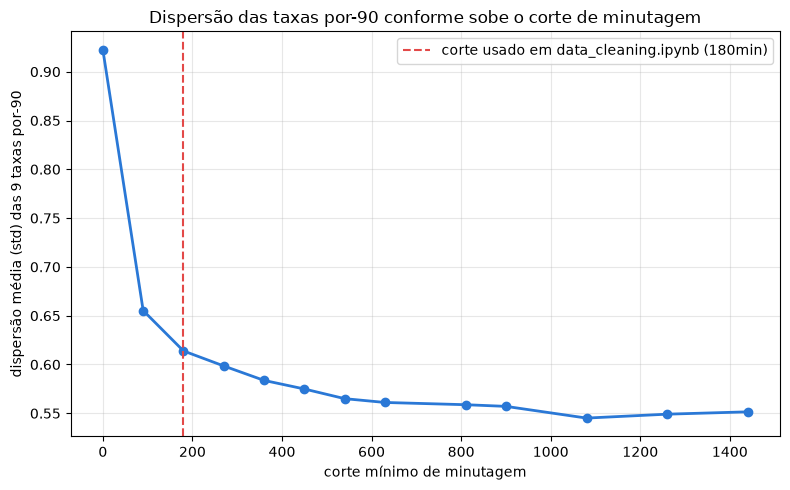

In [247]:
plt.figure(figsize=(8, 5))
plt.plot(tabela_dispersao['threshold_min'], tabela_dispersao['dispersao_media_std'],
         marker='o', linewidth=2, color='#2a78d6')
plt.axvline(180, color='#e34948', linestyle='--', linewidth=1.5,
            label='corte usado em data_cleaning.ipynb (180min)')
plt.xlabel('corte mínimo de minutagem')
plt.ylabel('dispersão média (std) das 9 taxas por-90')
plt.title('Dispersão das taxas por-90 conforme sobe o corte de minutagem')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Decisão:** Será aplicado um filtro de **180min** (2 jogos completos) na base de dados, para evitar outliers criados por jogadores que tiveram pouca minutagem.

### H3 — O filtro de minutagem deixa alguma classe pequena demais pro MLP?

**Hipótese:** depois do corte de 180min, as classes híbridas (`DFMF`, `MFDF`, `FWMF`, `MFFW`) ficam com poucos jogadores, algumas abaixo de 30, o que é pouco pra treinar uma classe de um classificador supervisionado.

In [248]:
antes = stats_df['Pos'].value_counts()
depois = stats_df.loc[stats_df['Min'] > 180, 'Pos'].value_counts()

tabela_balanceamento = pd.DataFrame({
    'antes_filtro': antes,
    'depois_filtro_180min': depois,
}).fillna(0).astype(int)

tabela_balanceamento = tabela_balanceamento.sort_values('depois_filtro_180min', ascending=False)
tabela_balanceamento['%_perdido'] = (
    100 * (1 - tabela_balanceamento['depois_filtro_180min'] / tabela_balanceamento['antes_filtro'])
).round(1)

tabela_balanceamento

,antes_filtro,depois_filtro_180min,%_perdido
Pos,,,
MF,259,194,25.1
DF,203,171,15.8
MFFW,61,61,0.0
FW,90,55,38.9
GK,51,44,13.7
FWMF,39,29,25.6
DFMF,31,28,9.7
MFDF,27,26,3.7


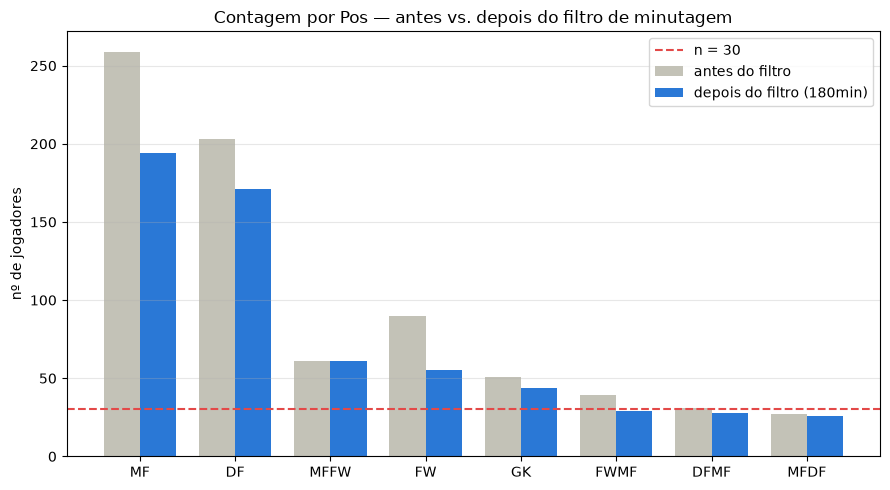

In [249]:
ordem_classes = tabela_balanceamento.index.tolist()
x = np.arange(len(ordem_classes))
largura = 0.38

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - largura/2, tabela_balanceamento['antes_filtro'], largura, label='antes do filtro', color='#c3c2b7')
ax.bar(x + largura/2, tabela_balanceamento['depois_filtro_180min'], largura, label='depois do filtro (180min)', color='#2a78d6')
ax.axhline(30, color='#e34948', linestyle='--', linewidth=1.5, label='n = 30')

ax.set_xticks(x)
ax.set_xticklabels(ordem_classes)
ax.set_ylabel('nº de jogadores')
ax.set_title('Contagem por Pos — antes vs. depois do filtro de minutagem')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

**Decisão:** O MLP não deve ser treinado com todas as 8 classes iniciais, pois tem classes híbridas que possuem poucos jogadores, e devem ser agregadas a outras classes. De qualquer forma será necessário usar estratificação no train/test split e considerar `class_weight='balanced'`.

### H4 — Quais híbridos têm perfil realmente distinto da posição pura?

**Hipótese:** das 4 posições híbridas (`DFMF`, `MFDF`, `MFFW`, `FWMF`), nem todas merecem classe própria no MLP, algumas são estatisticamente indistinguíveis da posição pura, enquanto outras carregam um perfil consistente e diferente.

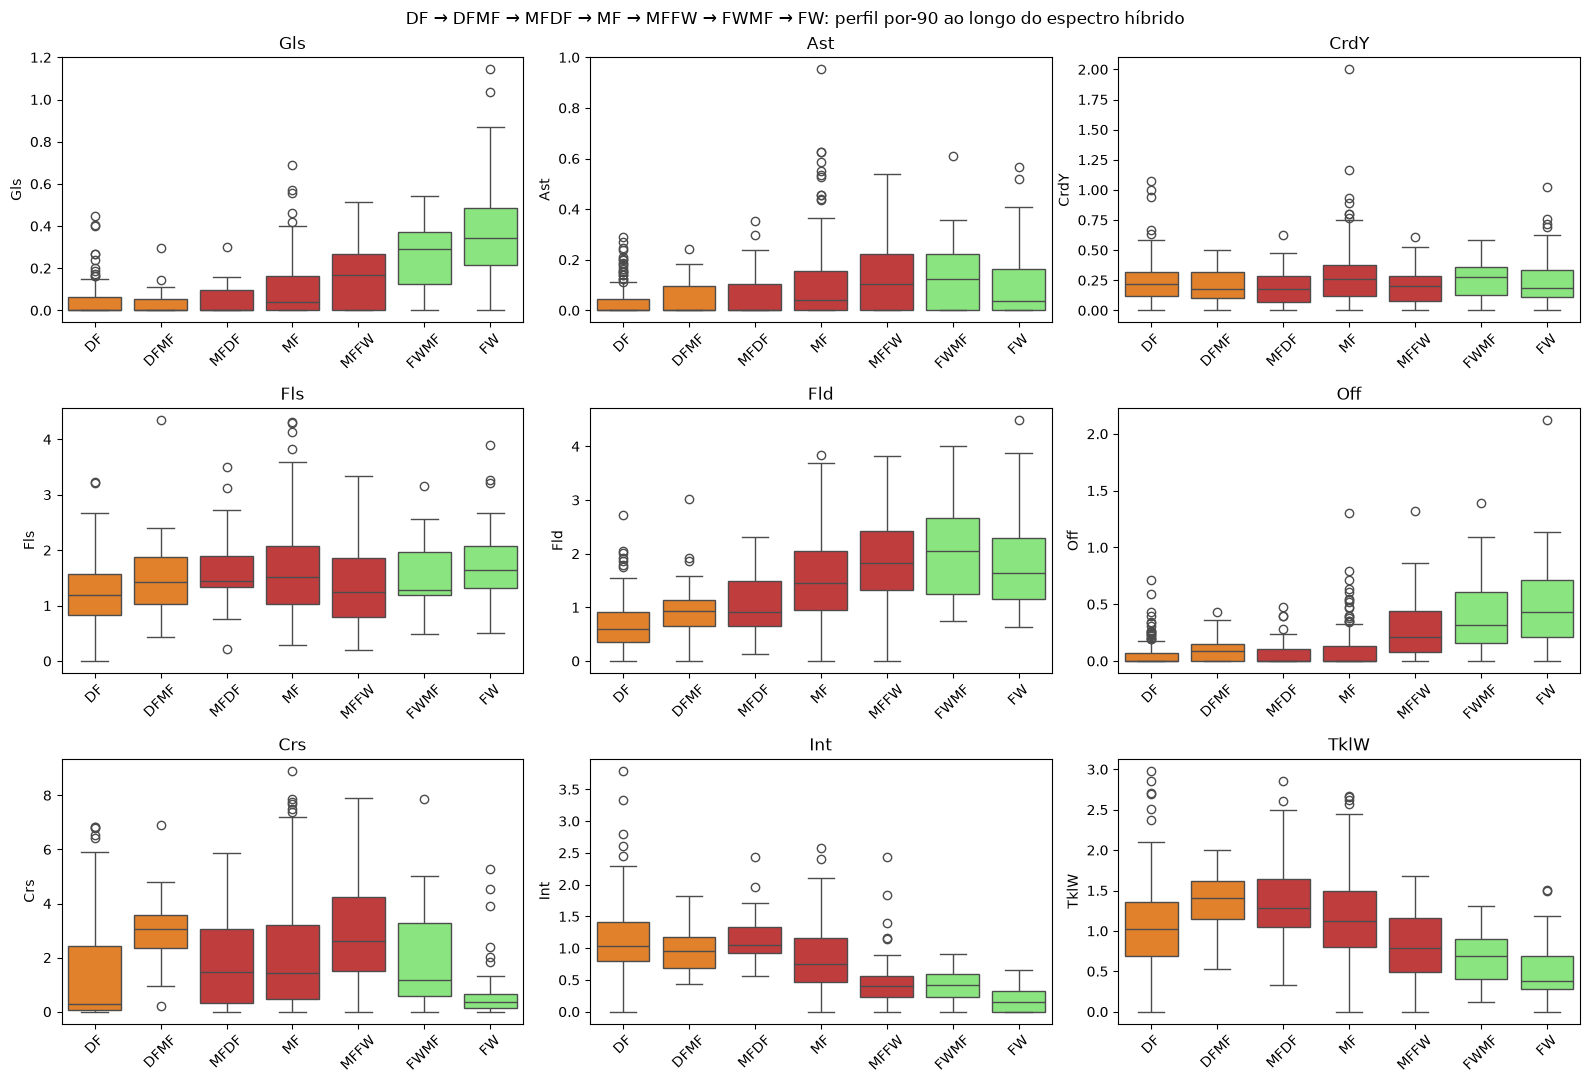

In [250]:
grupos_alvo = ['DF', 'DFMF', 'MFDF', 'MF', 'MFFW', 'FWMF', 'FW']

df_filtrado = stats_df[stats_df['Min'] > 180]
por90_hibridos = df_filtrado[colunas_evento].div(df_filtrado['90s'].replace(0, np.nan), axis=0)
por90_hibridos['Pos'] = df_filtrado['Pos']
por90_hibridos = por90_hibridos[por90_hibridos['Pos'].isin(grupos_alvo)]

fig, axes = plt.subplots(3, 3, figsize=(16, 11))
for ax, col in zip(axes.flat, colunas_evento):
    sns.boxplot(data=por90_hibridos, x='Pos', y=col, order=grupos_alvo, ax=ax, hue='Pos', palette={'DF': '#ff7f0e', 'DFMF': '#ff7f0e', 'MFDF': '#d62728', 'MF': '#d62728', 'MFFW': '#d62728', 'FWMF': "#7cf571", 'FW': '#7cf571'})
    ax.set_title(col)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('DF → DFMF → MFDF → MF → MFFW → FWMF → FW: perfil por-90 ao longo do espectro híbrido')
plt.tight_layout()
plt.show()

In [251]:
tabela_hibridos = por90_hibridos.groupby('Pos')[colunas_evento].median().round(2).T
tabela_hibridos = tabela_hibridos[grupos_alvo]
tabela_hibridos

Pos,DF,DFMF,MFDF,MF,MFFW,FWMF,FW
Gls,0.00,0.00,0.00,0.04,0.17,0.29,0.34
Ast,0.00,0.00,0.00,0.04,0.10,0.12,0.04
CrdY,0.22,0.18,0.18,0.26,0.21,0.27,0.19
Fls,1.20,1.42,1.45,1.51,1.25,1.27,1.65
Fld,0.59,0.93,0.91,1.45,1.83,2.05,1.63
Off,0.00,0.09,0.00,0.00,0.21,0.31,0.43
Crs,0.27,3.06,1.48,1.44,2.61,1.17,0.34
Int,1.04,0.96,1.05,0.75,0.40,0.42,0.16
TklW,1.02,1.41,1.28,1.13,0.79,0.68,0.39


In [252]:
def testar_diferenca(grupo_a, grupo_b, nome_a, nome_b):
    linhas = []
    for col in colunas_evento:
        _, p = mannwhitneyu(grupo_a[col], grupo_b[col], alternative='two-sided')
        linhas.append({
            'feature': col,
            f'mediana_{nome_a}': grupo_a[col].median(),
            f'mediana_{nome_b}': grupo_b[col].median(),
            'p_valor': round(p, 4),
            'diferente (p<0.05)': p < 0.05,
        })
    return pd.DataFrame(linhas)


pares = [('DF', 'DFMF'), ('MF', 'MFDF'), ('MF', 'MFFW'), ('FW', 'FWMF')]
resultados = {}
resumo = []

for pura, hibrida in pares:
    grupo_a = por90_hibridos[por90_hibridos['Pos'] == pura]
    grupo_b = por90_hibridos[por90_hibridos['Pos'] == hibrida]
    teste = testar_diferenca(grupo_a, grupo_b, pura, hibrida)
    resultados[hibrida] = teste

    print(f'{hibrida} vs. {pura} pura (n={len(grupo_a)} vs n={len(grupo_b)}):')
    display(teste)

    resumo.append({
        'hibrida': hibrida,
        'pura_de_referencia': pura,
        'n_hibrida': len(grupo_b),
        'features_significativas': int(teste['diferente (p<0.05)'].sum()),
    })

tabela_resumo = pd.DataFrame(resumo).sort_values('features_significativas', ascending=False)
print('\n=== Resumo: quão distinto é cada híbrido da posição pura ===')
tabela_resumo

DFMF vs. DF pura (n=171 vs n=28):


,feature,mediana_DF,mediana_DFMF,p_valor,diferente (p<0.05)
0,Gls,0.000000,0.000000,0.9053,False
1,Ast,0.000000,0.000000,0.1901,False
2,CrdY,0.217391,0.176070,0.7283,False
3,Fls,1.200000,1.420656,0.0253,True
4,Fld,0.588235,0.934551,0.0020,True
5,Off,0.000000,0.091392,0.0038,True
6,Crs,0.268456,3.060236,0.0000,True
7,Int,1.041667,0.962645,0.1023,False
8,TklW,1.020408,1.407154,0.0006,True


MFDF vs. MF pura (n=194 vs n=26):


,feature,mediana_MF,mediana_MFDF,p_valor,diferente (p<0.05)
0,Gls,0.038050,0.000000,0.1449,False
1,Ast,0.042763,0.000000,0.1763,False
2,CrdY,0.259180,0.176242,0.0422,True
3,Fls,1.509239,1.446201,0.7653,False
4,Fld,1.445993,0.911788,0.0033,True
5,Off,0.000000,0.000000,0.4253,False
6,Crs,1.437177,1.477053,0.6019,False
7,Int,0.746622,1.048704,0.0008,True
8,TklW,1.128426,1.279762,0.0471,True


MFFW vs. MF pura (n=194 vs n=61):


,feature,mediana_MF,mediana_MFFW,p_valor,diferente (p<0.05)
0,Gls,0.038050,0.168539,0.0001,True
1,Ast,0.042763,0.104712,0.0392,True
2,CrdY,0.259180,0.205479,0.0099,True
3,Fls,1.509239,1.250000,0.0096,True
4,Fld,1.445993,1.830065,0.0115,True
5,Off,0.000000,0.209790,0.0000,True
6,Crs,1.437177,2.613636,0.0001,True
7,Int,0.746622,0.400000,0.0000,True
8,TklW,1.128426,0.789474,0.0000,True


FWMF vs. FW pura (n=55 vs n=29):


,feature,mediana_FW,mediana_FWMF,p_valor,diferente (p<0.05)
0,Gls,0.341615,0.291667,0.0597,False
1,Ast,0.038610,0.125000,0.0701,False
2,CrdY,0.186335,0.274510,0.4765,False
3,Fls,1.645022,1.272727,0.0987,False
4,Fld,1.631944,2.054795,0.1384,False
5,Off,0.428571,0.313725,0.2810,False
6,Crs,0.344828,1.166667,0.0000,True
7,Int,0.156250,0.422535,0.0003,True
8,TklW,0.386100,0.684932,0.0111,True



=== Resumo: quão distinto é cada híbrido da posição pura ===


,hibrida,pura_de_referencia,n_hibrida,features_significativas
2,MFFW,MF,61,9
0,DFMF,DF,28,5
1,MFDF,MF,26,4
3,FWMF,FW,29,3


| híbrido | n | features significativas (de 9) |
|---|---|---|
| `MFFW` | 61 | **9** |
| `DFMF` | 28 | **5** |
| `MFDF` | 26 | **4** |
| `FWMF` | 29 | **3** |

- **`MFFW` (9/9):** perfil ofensivo consistente e inequívoco — mais `Crs`, `Off`, `Gls`, `Ast`, `Fld`; menos `Int`, `TklW`. Amostra confortável (61). Merece classe própria sem ressalva.
- **`DFMF` (5/9):** mais distinto do que `FWMF`, mesmo com amostra pequena (28). O salto em `Crs` (0.27→3.06, mais de 10×) sugere um perfil de lateral/ala ofensivo, não um DF genérico. 
- **`MFDF` (4/9):** diferença moderada (mais `Int`/`TklW`, menos `Fld` — um perfil de meio-campista mais defensivo), também com amostra pequena (26).
- **`FWMF` (3/9):** o mais fraco dos quatro — só diferem métricas de criação/defesa, não as de finalização. É o caso mais claro pra colapsar em `FW`.

**Decisão:** Apesar de DFMF e MFDF mostrarem um pouco de diferença, são classes que possuem poucos jogadores alocados nelas. A decisão vai ser utilizar 5 classes (GK, DF, MF, MFFW, FW) e agregar as outras classes híbridas nas suas posições primárias. Tenho que ver a possibilidade de usar DFMF como classe também, mas olhando o próprio dataset tem muitos laterais/alas que estão caracterizados só como DF.